In [14]:
import pandas as pd
import requests

# 1. Collect API Data using exact URL provided
url = "https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100"
response = requests.get(url)

if response.status_code == 200:
  data = response.json()

  # 2. Convert JSON response to Pandas DataFrame
  df = pd.DataFrame(data["items"])

  # 3. Select Required Columns
  required_cols = [
      "name",
      "owner",
      "language",
      "stargazers_count",
      "forks_count",
      "watchers_count",
      "open_issues_count",
      "created_at",
      "updated_at",
      "license",
  ]
  df_selected = df[required_cols].copy()

  # 4. Extract Required Values from Nested Columns
  df_selected["owner"] = df_selected["owner"].apply(
      lambda x: x["login"] if isinstance(x, dict) else None
  )
  df_selected["license"] = df_selected["license"].apply(
      lambda x: x["name"] if isinstance(x, dict) and x else "No License"
  )

  # 5. Handle Missing Values
  df_selected["language"] = df_selected["language"].fillna("Unknown")

  # 6. Handle Duplicate Records
  df_selected.drop_duplicates(inplace=True)

  # 7. Prepare the Dataset (Convert dates and rename columns)
  df_selected["created_at"] = pd.to_datetime(
      df_selected["created_at"]
  ).dt.date
  df_selected["updated_at"] = pd.to_datetime(
      df_selected["updated_at"]
  ).dt.date

  df_cleaned = df_selected.rename(
      columns={
          "stargazers_count": "stars",
          "forks_count": "forks",
          "watchers_count": "watchers",
          "open_issues_count": "open_issues",
          "created_at": "created_date",
          "updated_at": "updated_date",
      }
  )

  # 8. Save & Verify Dataset
  df_cleaned.to_csv("github_projects.csv", index=False)
  print("✅ Task 1 Completed: Saved as github_projects.csv")

  # Verification reload
  verify_df = pd.read_csv("github_projects.csv")
  display(verify_df.head(5))
else:
  print("❌ API Error:", response.status_code)

✅ Task 1 Completed: Saved as github_projects.csv


,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197032,76030,197032,2847,2015-11-07,2026-08-15,Apache License 2.0
1,transformers,huggingface,Python,164106,34250,164106,2384,2018-10-29,2026-08-15,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89400,21939,89400,11,2021-03-03,2026-08-15,MIT License
3,funNLP,fighting41love,Python,82472,15267,82472,53,2018-08-21,2026-08-15,No License
4,awesome-machine-learning,josephmisiti,Python,74037,15613,74037,24,2014-07-15,2026-08-15,Other


In [15]:
import sqlite3

# 1. Create SQLite Database & Store Dataset
conn = sqlite3.connect("github_data.db")
df_cleaned.to_sql("Repositories", conn, if_exists="replace", index=False)

print("--- Step 2: Filtering & Searching Queries ---")
# Query A: Filter repositories with more than 10,000 stars
q1 = "SELECT name, owner, stars, language FROM Repositories WHERE stars > 10000 LIMIT 5;"
display(pd.read_sql_query(q1, conn))

# Query B: Repositories whose names contain "Machine"
q2 = "SELECT name, owner, stars FROM Repositories WHERE name LIKE '%Machine%' LIMIT 5;"
display(pd.read_sql_query(q2, conn))

print("\n--- Step 3: Logical Operators (AND, OR, NOT) ---")
# Query 1 using AND / NOT
q3 = "SELECT name, language, stars FROM Repositories WHERE stars > 15000 AND NOT language = 'Python' LIMIT 5;"
display(pd.read_sql_query(q3, conn))

# Query 2 using OR / AND
q4 = "SELECT name, language, stars FROM Repositories WHERE (language = 'Python' OR language = 'C++') AND stars > 20000 LIMIT 5;"
display(pd.read_sql_query(q4, conn))

print("\n--- Step 4: Sorting & Top 10 Repositories ---")
q5 = "SELECT name, owner, stars, language FROM Repositories ORDER BY stars DESC LIMIT 10;"
top_10_df = pd.read_sql_query(q5, conn)
display(top_10_df)

print("\n--- Step 5: Aggregate Functions ---")
q6 = "SELECT COUNT(*) AS total_repositories, AVG(stars) AS average_stars FROM Repositories;"
display(pd.read_sql_query(q6, conn))

print("\n--- Step 6: Grouping Analysis (Languages with > 5 Repositories) ---")
q7 = """
SELECT language, COUNT(*) AS repo_count, AVG(stars) AS avg_stars
FROM Repositories
WHERE language != 'Unknown'
GROUP BY language
HAVING repo_count > 5
ORDER BY repo_count DESC;
"""
display(pd.read_sql_query(q7, conn))

--- Step 2: Filtering & Searching Queries ---


,name,owner,stars,language
0,tensorflow,tensorflow,197032,C++
1,transformers,huggingface,164106,Python
2,ML-For-Beginners,microsoft,89400,Jupyter Notebook
3,funNLP,fighting41love,82472,Python
4,awesome-machine-learning,josephmisiti,74037,Python


,name,owner,stars
0,awesome-machine-learning,josephmisiti,74037
1,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,36273
2,machine-learning-for-software-engineers,ZuzooVn,28857
3,homemade-machine-learning,trekhleb,24755
4,awesome-production-machine-learning,EthicalML,20846



--- Step 3: Logical Operators (AND, OR, NOT) ---


,name,language,stars
0,tensorflow,C++,197032
1,ML-For-Beginners,Jupyter Notebook,89400
2,500-AI-Machine-learning-Deep-learning-Computer...,Unknown,36273
3,C-Plus-Plus,C++,34583
4,netron,JavaScript,33353


...

,name,owner,stars,language
0,tensorflow,tensorflow,197032,C++
1,transformers,huggingface,164106,Python
2,ML-For-Beginners,microsoft,89400,Jupyter Notebook
3,funNLP,fighting41love,82472,Python
4,awesome-machine-learning,josephmisiti,74037,Python
5,scikit-learn,scikit-learn,66955,Python
6,gradio,gradio-app,43366,Python
7,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,36273,Unknown
8,C-Plus-Plus,TheAlgorithms,34583,C++
9,netron,lutzroeder,33353,JavaScript



--- Step 5: Aggregate Functions ---


,total_repositories,average_stars
0,100,20789.19



--- Step 6: Grouping Analysis (Languages with > 5 Repositories) ---


,language,repo_count,avg_stars
0,Python,30,26538.633333
1,Jupyter Notebook,19,17034.473684
2,C++,12,32171.750000


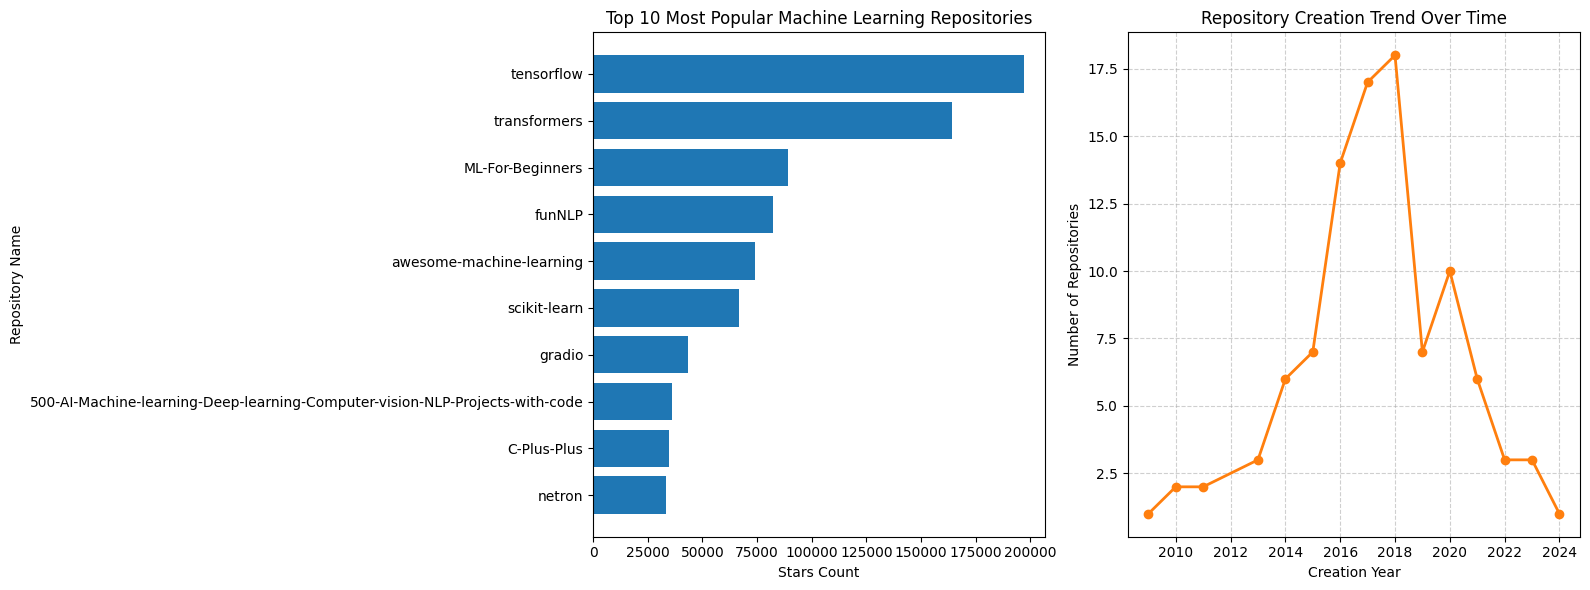

In [16]:
import matplotlib.pyplot as plt

# Step 7: Create Python Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Visualization 1: Top 10 Repositories by Stars
axes[0].barh(top_10_df["name"], top_10_df["stars"], color="#1f77b4")
axes[0].set_xlabel("Stars Count")
axes[0].set_ylabel("Repository Name")
axes[0].set_title("Top 10 Most Popular Machine Learning Repositories")
axes[0].invert_yaxis()

# Visualization 2: Yearly Repository Creation Trend
df_cleaned["created_year"] = pd.to_datetime(
    df_cleaned["created_date"]
).dt.year
yearly_counts = (
    df_cleaned["created_year"].value_counts().sort_index().reset_index()
)
yearly_counts.columns = ["year", "count"]

axes[1].plot(
    yearly_counts["year"],
    yearly_counts["count"],
    marker="o",
    linewidth=2,
    color="#ff7f0e",
)
axes[1].set_xlabel("Creation Year")
axes[1].set_ylabel("Number of Repositories")
axes[1].set_title("Repository Creation Trend Over Time")
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

conn.close()

# Task 3: Ethics Reflection

### 1. Why is it important to verify data collected from public APIs?
Public API data can contain missing values, structural changes, rate-limiting constraints, or unverified user inputs. Verification ensures that calculations, metrics, and downstream decisions are built on reliable information.

### 2. Why should data analysts document the source of their data?
Documenting data sources promotes transparency, reproducibility, and legal compliance. It enables stakeholders to audit the analytics pipeline and verify the origin and recency of the data used.

### 3. How can missing or inaccurate data affect data analysis and decision-making?
Missing or inaccurate data can distort statistical summaries, leading to biased conclusions, incorrect trends, and flawed strategic decisions that waste organizational resources.

In [17]:
!git config --global user.email "your_email@example.com"
!git config --global user.name "Your Name"

!git init
!git add .
!git commit -m "Initial commit: Completed GitHub Data Analytics Pipeline"
!git branch -M main

!git remote remove origin

!git remote add origin https://my_GITHUB_TOKEN@github.com/abdulrahman22-code/GitHub-data-analytics-pipeline.git

!git push -u origin main

Reinitialized existing Git repository in /content/.git/
[main 3a343a1] Initial commit: Completed GitHub Data Analytics Pipeline
 2 files changed, 9 insertions(+), 9 deletions(-)
fatal: could not read Password for 'https://my_GITHUB_TOKEN@github.com': No such device or address
